<a href="https://colab.research.google.com/github/Vishnubhatlapranav2004/11239A101_CV_Exp-s/blob/main/CV_Exp_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
import urllib.request

In [ ]:
# Face model
urllib.request.urlretrieve(
    'https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_frontalface_default.xml',
    'face.xml'
)

# Eye model
urllib.request.urlretrieve(
    'https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_eye.xml',
    'eye.xml'
)

# Smile model
urllib.request.urlretrieve(
    'https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_smile.xml',
    'smile.xml'
)

('smile.xml', <http.client.HTTPMessage at 0x7f02ec7ea150>)

In [ ]:
uploaded = files.upload()

Saving man.jpg to man.jpg


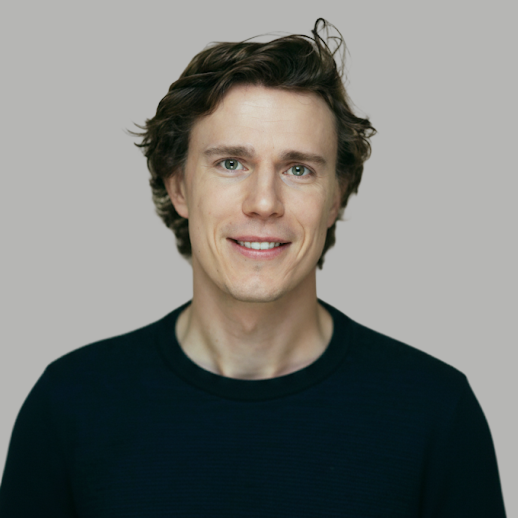

In [ ]:
img = cv2.imread('man.jpg')   # change filename
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2_imshow(img)

In [ ]:
face_cascade = cv2.CascadeClassifier('face.xml')
eye_cascade = cv2.CascadeClassifier('eye.xml')
smile_cascade = cv2.CascadeClassifier('smile.xml')

In [ ]:
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

In [ ]:
for (x, y, w, h) in faces:
    # Draw face rectangle
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # Eye detection
    eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 10)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # Smile detection
    smiles = smile_cascade.detectMultiScale(roi_gray, 1.7, 20)
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

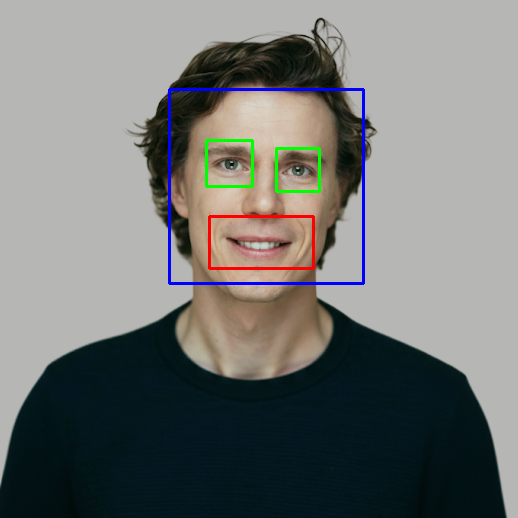

In [ ]:
cv2_imshow(img)